In [1]:
import torch
import torch.nn as nn

import torch_geometric as tg
import torch_geometric.utils as tgu
import torch_geometric.nn as tgnn
import matplotlib.pyplot as plt

import numpy as np

In [2]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(DEVICE)

cuda


## Notes from graphcast
 - there are multiple layers of nodes -> some nodes propagate information to more distant nodes
 - loss function takes into account multiple factors - e.g. sample density
 - autoregressive training 
   - model is trained using fix interval
   - to predict more distant (in time) points then previous prediction of a model is used
   - predicting 10 day ahead tends to have large overfitting
 - gnn was selected because weather function is the same in every place of the globe

In [12]:
omega = 1.8

feature_vec_len = 16
edge_vec_len = 16
brain_size = 64
x = np.arange(0,6.4,0.1).reshape((-1,1))
t = np.arange(0,6,0.1).reshape([-1,1])


values = np.sin(omega*t+x.T)

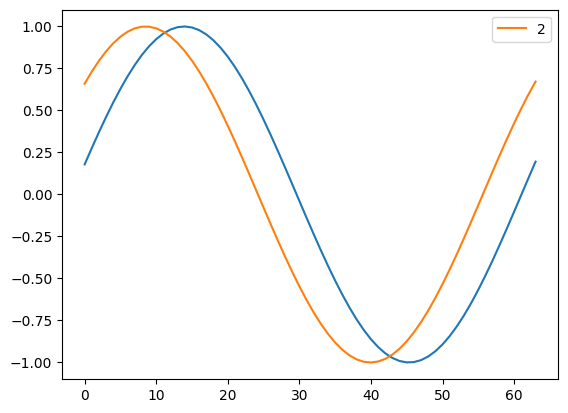

In [13]:
plt.plot(values[1,:])
plt.plot(values[4,:], label='2')
plt.legend()

In [14]:
np.random.randn(1).item()/3

-0.04562426221767879

In [98]:
fully_connected_adj = torch.ones(values.shape[0]+brain_size, values.shape[0]+brain_size)
fully_connected_adj[brain_size:, brain_size:] = 0
fully_connected_adj

tensor([[1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        ...,
        [1., 1., 1.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.]])

In [99]:
def get_sample(values, dt=4, inclusion_prob=0.5, poison_prob=0.1):
    time_horizon, positions = values.shape

    fully_connected_adj = torch.ones(positions+brain_size, positions+brain_size)
    fully_connected_adj[brain_size:, brain_size:] = 0
    fully_connected = tgu.dense_to_sparse(fully_connected_adj)[0]
    placeholder = np.zeros([brain_size, 5])

    sample = []
    sample_dt = []

    time_stamp = np.random.randint(dt, time_horizon - 2*dt)
    time_to_predict = time_stamp + np.random.randint(1, 2*dt)

    is_included = np.random.random(positions) < inclusion_prob
    #is_poisoned = np.random.random(positions) < poison_prob
    #for idx, included, poisoned  in zip(range(positions), is_included, is_poisoned):
    for idx, included  in zip(range(positions), is_included):
        _time = time_stamp + np.random.randint(-dt, dt)
        sample.append((
            (idx+1)/positions,
            included*1.0,
            values[_time, idx] * included, #+ poisoned * np.random.randn(1).item()/3,
            _time/64,
            time_to_predict/64,
        ))
        sample_dt.append((
            (idx+1)/positions,
            1.0,
            values[time_to_predict, idx],
            time_to_predict/64,
            time_to_predict/64,
        ))

    return tg.data.Data(
        x=torch.tensor(np.concatenate([placeholder, sample], axis=0), dtype=torch.float32, requires_grad=False),
        edge_index=fully_connected,
        y=torch.tensor(sample_dt, dtype=torch.float32, requires_grad=False)
    )

In [100]:
sample = get_sample(values)

In [101]:
class AutoEncoder(nn.Module):
    def __init__(self, input_size, hidden_size=8, input_size_expander=4):
        nn.Module.__init__(self)
        
        # Set the number of hidden units
        self.num_hidden = hidden_size
        
        # Define the encoder part of the autoencoder
        self.encoder = nn.Sequential(
            nn.Linear(input_size, input_size_expander*input_size),  # input size: 784, output size: 256
            nn.GELU(),  # apply the ReLU activation function
            nn.Linear(input_size_expander*input_size, self.num_hidden),  # input size: 256, output size: num_hidden
            nn.GELU(),  # apply the ReLU activation function
        )
        
        # Define the decoder part of the autoencoder
        self.decoder = nn.Sequential(
            nn.Linear(self.num_hidden, input_size_expander*input_size),  # input size: num_hidden, output size: 256
            nn.GELU(),  # apply the ReLU activation function
            nn.Linear(input_size_expander*input_size, input_size_expander*input_size),  # input size: num_hidden, output size: 256
            nn.GELU(),  # apply the ReLU activation function
            nn.Linear(input_size_expander*input_size, input_size),  # input size: 256, output size: 784
        )

    def forward(self, x):
        # Pass the input through the encoder
        encoded = self.encoder(x)
        # Pass the encoded representation through the decoder
        decoded = self.decoder(encoded)
        # Return both the encoded representation and the reconstructed output
        return encoded, decoded

In [102]:
ae = AutoEncoder(3, hidden_size=feature_vec_len,input_size_expander=8)
ae_dataset = torch.cat([get_sample(values).x[64:,:3] for _ in range(4096)])
batch_size = 64
num_epochs = 2

optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)

# Define the loss function
criterion = nn.MSELoss()

# Set the device to GPU if available, otherwise use CPU
ae.to(DEVICE)

# Create a DataLoader to handle batching of the training data
train_loader = torch.utils.data.DataLoader(
    ae_dataset, batch_size=64, shuffle=True
)

for epoch in range(num_epochs):
    total_loss = 0.0
    for batch_idx, data in enumerate(train_loader):
        # Get a batch of training data and move it to the device
        data = data.to(DEVICE)

        # Forward pass
        encoded, decoded = ae(data)

        # Compute the loss and perform backpropagation
        loss = criterion(decoded, data)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update the running loss
        total_loss += loss.item() * data.size(0)

    # Print the epoch loss
    epoch_loss = total_loss / len(train_loader.dataset)
    print(
        "Epoch {}/{}: loss={:.6f}".format(epoch + 1, num_epochs, epoch_loss)
    )

Epoch 1/2: loss=0.008299
Epoch 2/2: loss=0.000003


In [103]:
sample = get_sample(values)
ae.decoder(
    ae.encoder(sample.x[:,:3].to(DEVICE))
)

tensor([[ 1.0932e-03, -6.1691e-06,  6.6008e-04],
        [ 1.0932e-03, -6.1691e-06,  6.6008e-04],
        [ 1.0932e-03, -6.1691e-06,  6.6008e-04],
        [ 1.0932e-03, -6.1691e-06,  6.6008e-04],
        [ 1.0932e-03, -6.1691e-06,  6.6008e-04],
        [ 1.0932e-03, -6.1691e-06,  6.6008e-04],
        [ 1.0932e-03, -6.1691e-06,  6.6008e-04],
        [ 1.0932e-03, -6.1691e-06,  6.6008e-04],
        [ 1.0932e-03, -6.1691e-06,  6.6008e-04],
        [ 1.0932e-03, -6.1691e-06,  6.6008e-04],
        [ 1.0932e-03, -6.1691e-06,  6.6008e-04],
        [ 1.0932e-03, -6.1691e-06,  6.6008e-04],
        [ 1.0932e-03, -6.1691e-06,  6.6008e-04],
        [ 1.0932e-03, -6.1691e-06,  6.6008e-04],
        [ 1.0932e-03, -6.1691e-06,  6.6008e-04],
        [ 1.0932e-03, -6.1691e-06,  6.6008e-04],
        [ 1.0932e-03, -6.1691e-06,  6.6008e-04],
        [ 1.0932e-03, -6.1691e-06,  6.6008e-04],
        [ 1.0932e-03, -6.1691e-06,  6.6008e-04],
        [ 1.0932e-03, -6.1691e-06,  6.6008e-04],
        [ 1.0932e-03

In [112]:
sample.edge_index.shape

torch.Size([2, 12288])

In [122]:
# x_cord, y_cord, time
# time_embed 
ae.decoder.requires_grad_(False)
ae.encoder.requires_grad_(False)

class gnn_model(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        self.gnn_out_ch = 32
        self.edge_vector_len = edge_vec_len*2
        edge_params_shape = values.shape[1]**2
        self.fe = ae.encoder
        self.fd = ae.decoder
        #self.edge_params = nn.Parameter(torch.randn([64, self.edge_vector_len])/20)
        self.edge_params = nn.Parameter(torch.randn([12288, self.edge_vector_len])/20)
        self.brain = nn.Parameter(torch.randn([brain_size, feature_vec_len+2])/20)

        self.l1 = tgnn.GAT(
            in_channels=feature_vec_len+2,
            hidden_channels=4*feature_vec_len,
            num_layers=3,
            out_channels=feature_vec_len,
            dropout=0.1,
            act='gelu',
            edge_dim=self.edge_vector_len,
            v2=True,
        )

        self.bsize_edge_params = torch.cat([self.edge_params]*(2048//64))
        self.training_mode = False
    def forward(self, data):
        nodes = data.x
        edges = data.edge_index
        encoded_features = self.fe(nodes[:,:3])
        nodes_inp  = torch.cat([encoded_features, nodes[:,3:]], dim=1)

        brain_spots = (nodes[:,0] == 0)
        nof_copies = nodes[brain_spots].shape[0] // brain_size

        nodes_inp[brain_spots] = torch.cat([self.brain]*nof_copies)
        
        #g_output = self.l1(nodes_inp, edges, edge_attr=torch.cat([self.edge_params]*(edges.shape[1]//self.edge_params.shape[0])))
        g_output = self.l1(nodes_inp, edges, edge_attr=self.edge_params.repeat(edges.shape[1]//self.edge_params.shape[0], 1))
        decoded = self.fd(g_output)

        return decoded[~brain_spots,-2:]



In [146]:
model = gnn_model()
model.to(DEVICE)
with torch.no_grad():
    print(model(sample.to(DEVICE)).shape)

torch.Size([64, 2])


In [157]:
NUM_TR_STEPS = 80
BATCH_SIZE = 32
model.training_mode = True
loss_t_0 = []
loss_t_dt = []
# optimizers = [
#     torch.optim.AdamW([model.brain],lr=1e-4,weight_decay=0.1),
#     torch.optim.AdamW([model.edge_params],lr=1e-4,weight_decay=0.1),
#     torch.optim.AdamW(model.l1.parameters(),lr=1e-3,),
# ]
optimizers = [torch.optim.AdamW(model.parameters(),lr=2e-3,)]
loss_fn = nn.MSELoss()
data_list = [get_sample(values,inclusion_prob=np.random.randint(20,90)/100) for _ in range(8192*2)]
#data_list = [get_sample(values,inclusion_prob=0.5) for _ in range(8192)]
dl = tg.data.DataLoader(data_list, batch_size=2)
dl2 = tg.data.DataLoader(data_list, batch_size=64)
warmup_steps = 2

for i in range(NUM_TR_STEPS):
    if i == warmup_steps:
        dl = dl2
        # optimizers = [
        #     torch.optim.AdamW([model.brain],lr=4e-4,),
        #     torch.optim.AdamW([model.edge_params],lr=4e-4,),
        #     torch.optim.AdamW(model.l1.parameters(),lr=4e-3,),
        # ]   

    for idx, batch in enumerate(dl):
        print(f"IDX: {idx}", end='\r')
        batch = batch.to(DEVICE)
        y_hat = model(batch)

        loss = loss_fn(batch.y[:,-3], y_hat[:,-1])

        # check if this is correct place for zero grad
        optimizer.zero_grad()
        loss.backward()

        #optimizer.step()
        for optimizer in optimizers:
            optimizer.step()

        if idx%16 == 0 and i>=warmup_steps:
            l_dt = loss.detach().cpu().item()
            loss_t_dt.append(l_dt)
            print(f"l_dt:{l_dt}")
        elif idx%1024 == 0 and i<warmup_steps:
            l_dt = loss.detach().cpu().item()
            loss_t_dt.append(l_dt)
            print(f"l_dt:{l_dt}")

l_dt:0.0030228958930820227
l_dt:0.00557467807084322
l_dt:0.012481018900871277
l_dt:0.003438125364482403
l_dt:0.0025037946179509163
l_dt:0.006244735326617956
l_dt:0.009223466739058495
l_dt:0.011627361178398132
l_dt:0.0025570993311703205
l_dt:0.0075345528312027454
l_dt:0.005022616591304541
l_dt:0.005311142187565565
l_dt:0.003939041867852211
l_dt:0.0036624735221266747
l_dt:0.011049941182136536
l_dt:0.00247618043795228
l_dt:0.005062208976596594
l_dt:0.004232756327837706
l_dt:0.0035437438637018204
l_dt:0.002813322702422738
l_dt:0.0029044090770184994
l_dt:0.0034132017754018307
l_dt:0.002942493883892894
l_dt:0.002598346211016178
l_dt:0.0026714932173490524
l_dt:0.002237762790173292
l_dt:0.003019568743184209
l_dt:0.0025960151106119156
l_dt:0.0026242462918162346
l_dt:0.0026939515955746174
l_dt:0.0020445433910936117
l_dt:0.0021855353843420744
l_dt:0.002590807620435953
l_dt:0.002885871334001422
l_dt:0.0028524277731776237
l_dt:0.0023704790510237217
l_dt:0.002578871790319681
l_dt:0.00344230444170534

KeyboardInterrupt: 

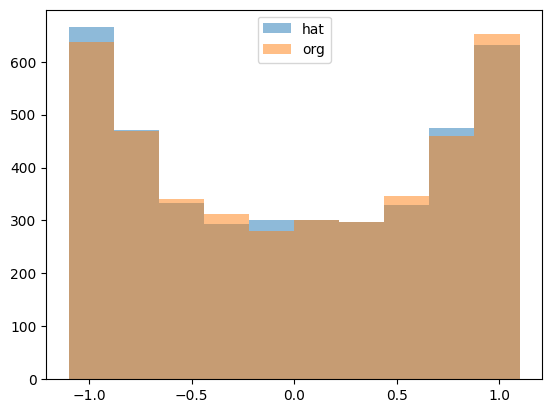

In [158]:
plt.hist(y_hat[:,-1].detach().cpu().flatten().numpy(), alpha=.5, label='hat', range=(-1.1,1.1))
plt.hist(batch.y[:,-3].detach().cpu().flatten().numpy(), alpha=.5, label='org', range=(-1.1,1.1))
plt.legend()

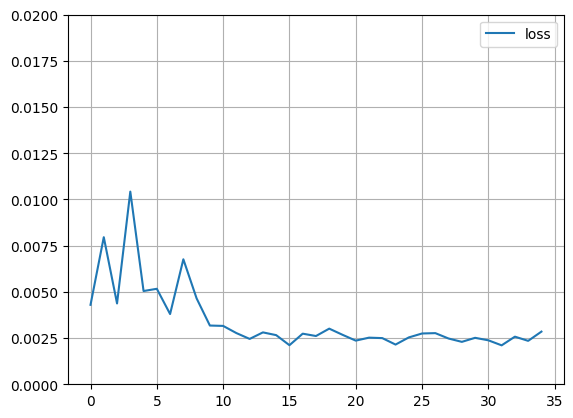

In [159]:
mean_over = 2

t_dt = np.array(loss_t_dt)
t_dt_mean = t_dt[t_dt.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

plt.plot(t_dt_mean, label='loss')
plt.legend()
plt.ylim(0.0,.02)
plt.grid()
plt.show()

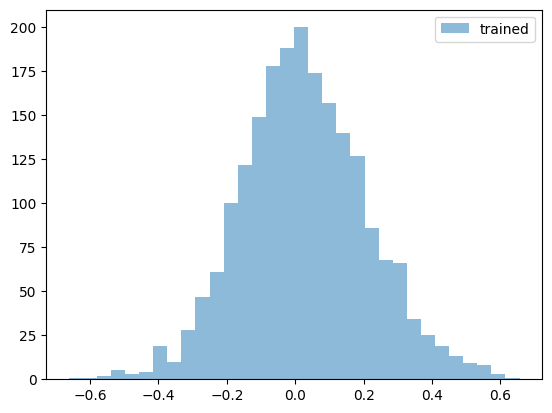

In [160]:
plt.hist([*model.l1.parameters()][-8].detach().flatten().cpu(), bins=32, label='trained', alpha=0.5)
plt.legend()
plt.show()

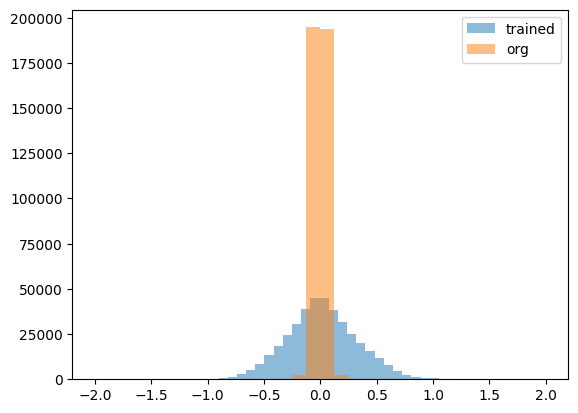

In [161]:
plt.hist(model.edge_params.detach().flatten().cpu(), bins=32, label='trained', alpha=0.5)
plt.hist((torch.randn(model.edge_params.shape)/20).flatten(), bins=32, label='org', alpha=0.5,range=(-2,2))
plt.legend()
plt.show()

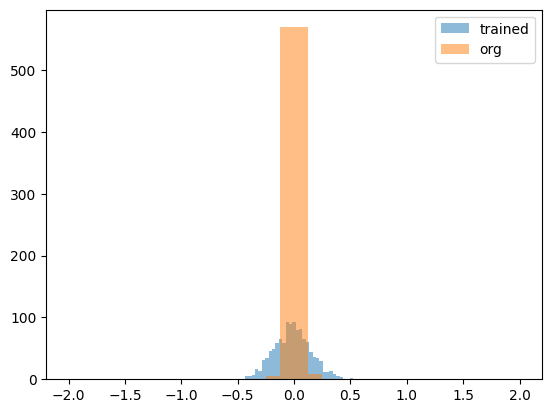

In [162]:
plt.hist(model.brain.detach().flatten().cpu(), bins=32, label='trained', alpha=0.5)
plt.hist((torch.randn(model.brain.shape)/20).flatten(), bins=32, label='org', alpha=0.5,range=(-2,2))
plt.legend()
plt.show()

MSE: 0.49948522448539734
MSE: 0.0690423846244812
MSE: 0.0020702697802335024


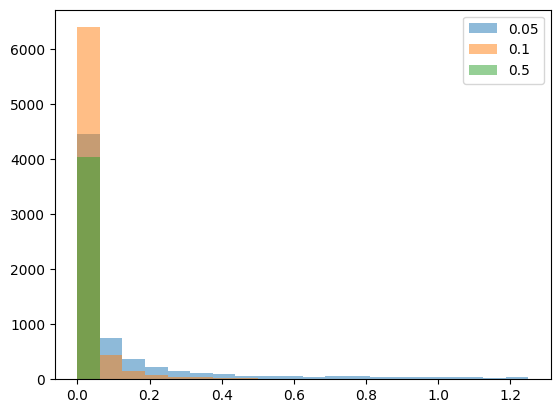

RMSE: 0.433684766292572
RMSE: 0.13929101824760437
RMSE: 0.034859854727983475


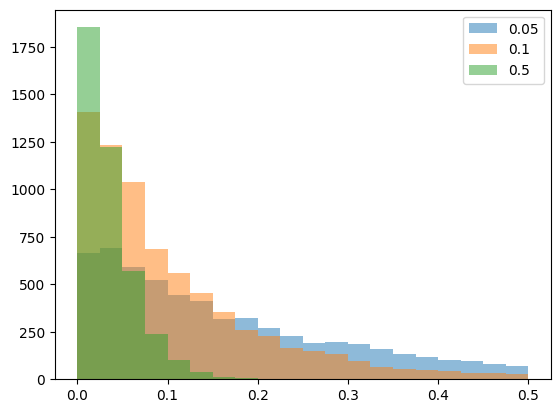

mean: 2.3516721725463867
mean: 0.7221831679344177
mean: 0.19541360437870026


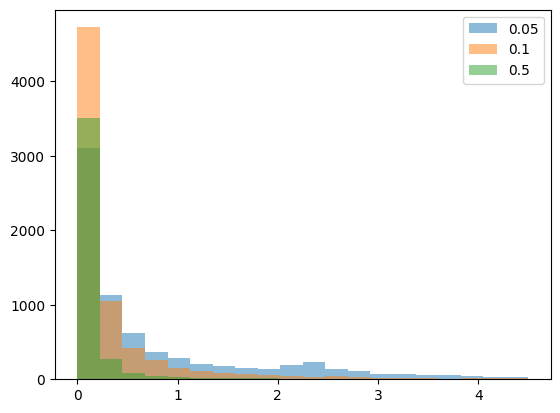

In [186]:
NUM_TEST_STEPS = 128
res_dict = {}
percent_res_dict = {}
model.training_mode = False
with torch.no_grad():
    for inc_prob in [.05,.1,.5]:
        loss_te_dt = []
        loss_te_dt_percent = []
        for i in range(NUM_TEST_STEPS):
            sample = get_sample(values,inclusion_prob=inc_prob).to(DEVICE)

            y_hat = model(
                sample
            )
            mask = ~(sample.x[brain_size:, -3]!=0)
            l_dt = ((sample.y[:,-3][mask] - y_hat[:,-1][mask])**2).T
            percent_res = torch.abs(sample.y[:,-3][mask] - y_hat[:,-1][mask]) / (torch.abs(sample.y[:,-3][mask])+.0001)
            loss_te_dt.append(l_dt.detach())
            loss_te_dt_percent.append(percent_res.detach())

        res_dict[inc_prob] = torch.cat(loss_te_dt).cpu().numpy()
        percent_res_dict[inc_prob] = torch.cat(loss_te_dt_percent).cpu().numpy()

for label, part_res in res_dict.items():
    plt.hist(part_res,range=(0,1.25), alpha=0.5, label=str(label), bins=20)
    print(f"MSE: {np.mean(part_res)}")
plt.legend()
plt.show()

for label, part_res in res_dict.items():
    plt.hist(part_res**0.5,range=(0,.5), alpha=0.5, label=str(label), bins=20)
    print(f"RMSE: {np.mean(part_res**0.5)}")
plt.legend()
plt.show()

for label, part_res in percent_res_dict.items():
    plt.hist(part_res, range=(0,4.5), alpha=0.5, label=str(label), bins=20)
    print(f"mean: {np.mean(part_res)}")
plt.legend()
plt.show()

MSE: 0.39992755651474
MSE: 0.3498603105545044
MSE: 0.39666125178337097


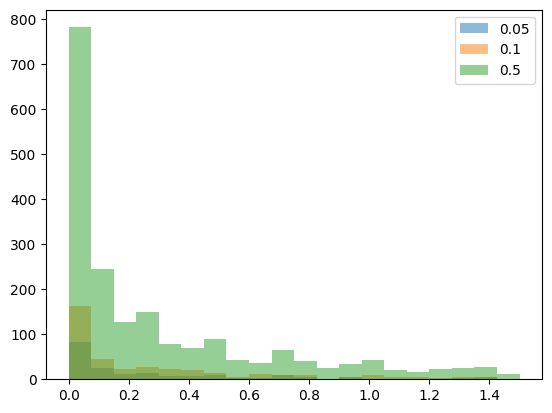

RMSE: 0.4901673197746277
RMSE: 0.4529915750026703
RMSE: 0.48919349908828735


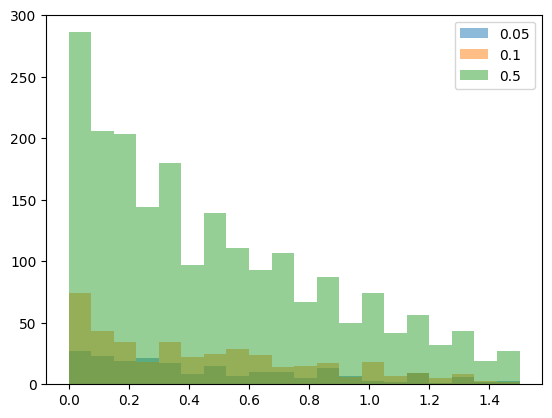

mean: 3.0237412452697754
mean: 1.9841562509536743
mean: 2.4689252376556396


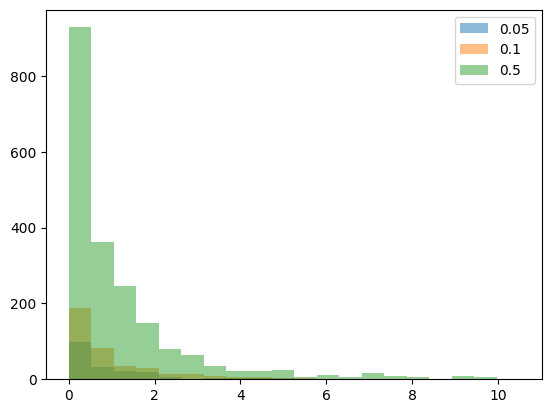

In [ ]:
NUM_TEST_STEPS = 128
res_dict = {}
percent_res_dict = {}

with torch.no_grad():
    for inc_prob in [.05,.1,.5]:
        loss_te_dt = []
        loss_te_dt_percent = []
        for i in range(NUM_TEST_STEPS):
            sample = get_sample(values,inclusion_prob=inc_prob)
            mask = sample.x[brain_size:, -3]!=0
            l_dt = ((sample.y[:,-3][mask] - sample.x[brain_size:,-3][mask])**2).T
            percent_res = torch.abs(sample.y[:,-3][mask]- sample.x[64:,-3][mask]) / (torch.abs(sample.y[:,-3][mask])+.0001)
            loss_te_dt.append(l_dt.detach())
            loss_te_dt_percent.append(percent_res.detach())

        res_dict[inc_prob] = torch.cat(loss_te_dt).cpu().numpy()
        percent_res_dict[inc_prob] = torch.cat(loss_te_dt_percent).cpu().numpy()

for label, part_res in res_dict.items():
    plt.hist(part_res,range=(0,1.5), alpha=0.5, label=str(label), bins=20)
    print(f"MSE: {np.mean(part_res)}")
plt.legend()
plt.show()

for label, part_res in res_dict.items():
    plt.hist(part_res**0.5,range=(0,1.5), alpha=0.5, label=str(label), bins=20)
    print(f"RMSE: {np.mean(part_res**0.5)}")
plt.legend()
plt.show()

for label, part_res in percent_res_dict.items():
    plt.hist(part_res, range=(0,10.5), alpha=0.5, label=str(label), bins=20)
    print(f"mean: {np.mean(part_res)}")
plt.legend()
plt.show()

In [178]:
sample = get_sample(values,inclusion_prob=0.05)
sample.x[brain_size:, -3]!=0

tensor([ True,  True, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
         True, False, False, False,  True, False, False, False, False, False,
        False, False, False, False])